# Assignment 4

This is an basecode for assignment 4 of Artificial Intelligence class (CSCE-4613), Spring 2025


In [37]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt

## Binary Network

## Define a binary network class


In [38]:
class BinaryNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden = nn.Linear(2, 4)
    self.output = nn.Linear(4, 1)

  def forward(self, x):
    x = torch.relu(self.hidden(x))
    x = torch.sigmoid(self.output(x))
    return x.squeeze(1)

italicized text### Define data generator

In [39]:
def generate_data(operator = "AND"):
  assert operator in ["AND", "OR", "XOR", "NOR"], "%s operator is not valid" % operator
  data = []
  label = []
  for i in range(2):
    for j in range(2):
      data.append([i, j])
      if operator == "AND":
        label.append(i & j)
      elif operator == "OR":
        label.append(i | j)
      elif operator == "XOR":
        label.append(i ^ j)
      else:
        label.append(not (i | j))
  data = torch.as_tensor(data, dtype = torch.float32)
  label = torch.as_tensor(label, dtype = torch.float32)
  return data, label

### Define the training framework

BinaryNetwork(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)
[5/1000]. Loss: 0.5509. Accuracy: 0.75
[10/1000]. Loss: 0.4948. Accuracy: 0.75
[15/1000]. Loss: 0.4163. Accuracy: 0.75
[20/1000]. Loss: 0.3464. Accuracy: 0.75
[25/1000]. Loss: 0.2939. Accuracy: 0.75
[30/1000]. Loss: 0.2428. Accuracy: 0.75
[35/1000]. Loss: 0.1858. Accuracy: 1.00
[40/1000]. Loss: 0.1460. Accuracy: 1.00
[45/1000]. Loss: 0.1130. Accuracy: 1.00
[50/1000]. Loss: 0.0881. Accuracy: 1.00
[55/1000]. Loss: 0.0708. Accuracy: 1.00
[60/1000]. Loss: 0.0581. Accuracy: 1.00
[65/1000]. Loss: 0.0479. Accuracy: 1.00
[70/1000]. Loss: 0.0408. Accuracy: 1.00
[75/1000]. Loss: 0.0359. Accuracy: 1.00
[80/1000]. Loss: 0.0319. Accuracy: 1.00
[85/1000]. Loss: 0.0278. Accuracy: 1.00
[90/1000]. Loss: 0.0254. Accuracy: 1.00
[95/1000]. Loss: 0.0234. Accuracy: 1.00
[100/1000]. Loss: 0.0218. Accuracy: 1.00
[105/1000]. Loss: 0.0202. Accuracy: 1.00
[110/1000]. Loss: 0.

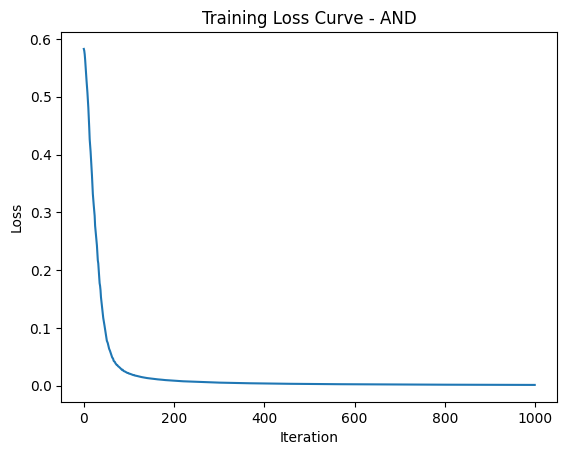

Final Accuracy: 1.00


In [40]:
model = BinaryNetwork()
model.train()
print(model)

# set the operator
operator = "AND"
# get dataset
inputs, labels = generate_data(operator = operator)

n_iters = 1000
learning_rate = 0.1

optim = torch.optim.SGD(params = model.parameters(), lr = learning_rate, momentum=0.9)

# compares predicted probability to their binary label
loss_fn = nn.BCELoss()
losses = []

for i in range(1, n_iters + 1):
  # predict output for all 4 truth table rows
  predictions = model(inputs)
  # compute the loss and see how wrong our predictor is
  loss = loss_fn(predictions, labels)

  # round the outputs and make it either 0 or 1
  preds = (predictions >= 0.5).float()

  # this checks which predictions match labels
  accuracy = (preds == labels).float().mean().item()

  # because PyTorch does gradients already we must clear
  # them, backpropagate, and update weights
  optim.zero_grad()
  loss.backward()
  optim.step()

  # populate the losses list
  losses.append(loss.item())

  if i % 5 == 0:
    print("[%d/%d]. Loss: %0.4f. Accuracy: %0.2f" % (i, n_iters, loss.item(), accuracy))


plt.plot(losses)
plt.title(f"Training Loss Curve - {operator}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

model.eval()

# after training reevalutate
outputs = model(inputs)
preds = (outputs >= 0.5).float()
accuracy = (preds == labels).float().mean().item()


print("Final Accuracy: %0.2f" % (accuracy))
torch.save(model.state_dict(), "%s_Network.pth" % operator)
  # model.load_state_dict(torch.load("%s_Network.pth" % operator)) # Load model in the next time you use

## Digit Classification

### Define Digit Classification Network

In [41]:
class DigitNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    # unwraps image into one row of numbers
    self.flatten = nn.Flatten()
    # first layer has 1 x 28 x 28 (784) pixels
    # then turns them into 128 learned features
    self.hidden1 = nn.Linear(28 * 28, 128)
    # now compress and refeature
    self.hidden2 = nn.Linear(128, 64)
    # now give 10 scores from the 64 features
    # each score will correspond to digits 0...9
    self.output = nn.Linear(64, 10)

  def forward(self, x):
    # x starts as (batch_size, 1, 28, 28)
    x = self.flatten(x)        # becomes (batch_size, 784)
    x = self.hidden1(x)        # becomes (batch_size, 128)
    x = torch.relu(x)
    x = self.hidden2(x)        # becomes (batch_size, 64)
    x = torch.relu(x)          # makes the network nonlinear
    x = self.output(x)         # becomes (batch_size, 10)
    return x

### Define Data Generator

In [42]:
def create_data_generator(batch_size = 32, root = "data"):
  train_dataset = torchvision.datasets.MNIST(root = root, train = True, transform = torchvision.transforms.ToTensor(), download = True)
  test_dataset = torchvision.datasets.MNIST(root = root, train = False, transform = torchvision.transforms.ToTensor(), download = True)
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
  test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
  return train_loader, test_loader

### Define the training framework

DigitNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/1]. Iter [1/1875]. Loss: 2.31. Accuracy: 0.06
Epoch [1/1]. Iter [101/1875]. Loss: 0.57. Accuracy: 0.91
Epoch [1/1]. Iter [201/1875]. Loss: 0.71. Accuracy: 0.78
Epoch [1/1]. Iter [301/1875]. Loss: 0.57. Accuracy: 0.78
Epoch [1/1]. Iter [401/1875]. Loss: 0.56. Accuracy: 0.84
Epoch [1/1]. Iter [501/1875]. Loss: 0.23. Accuracy: 0.91
Epoch [1/1]. Iter [601/1875]. Loss: 0.43. Accuracy: 0.94
Epoch [1/1]. Iter [701/1875]. Loss: 0.26. Accuracy: 0.94
Epoch [1/1]. Iter [801/1875]. Loss: 0.10. Accuracy: 1.00
Epoch [1/1]. Iter [901/1875]. Loss: 0.28. Accuracy: 0.94
Epoch [1/1]. Iter [1001/1875]. Loss: 0.17. Accuracy: 0.91
Epoch [1/1]. Iter [1101/1875]. Loss: 0.34. Accuracy: 0.88
Epoch [1/1]. Iter [1201/1875]. Loss: 0.55. Accuracy: 0.91
Ep

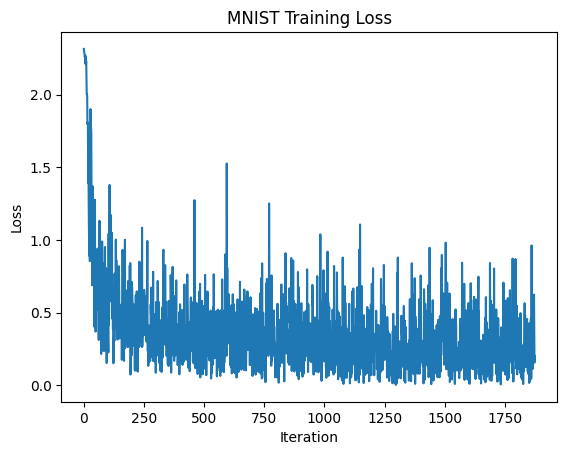

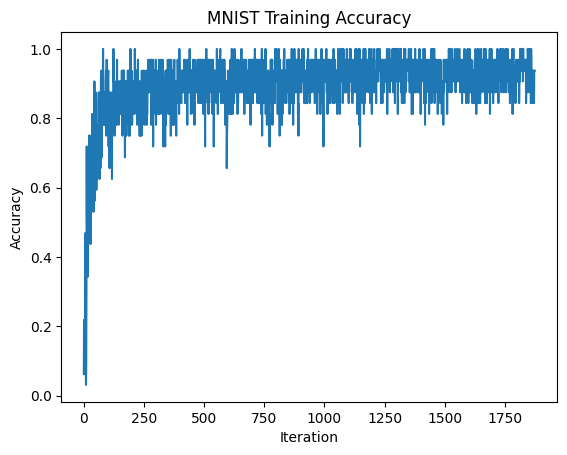

In [43]:
import time

cuda = torch.cuda.is_available()
batch_size = 32
train_loader, test_loader = create_data_generator(batch_size)

model = DigitNetwork()
print(model)

if cuda:
  model.cuda()

n_epochs = 1
learning_rate = 0.1

optim = torch.optim.SGD(params = model.parameters(), lr = learning_rate, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()


train_losses = []
train_accuracies = []
iteration_times = []

model.train()
training_start = time.time()

for epoch in range(1, n_epochs + 1):
  for idx, (images, labels) in enumerate(train_loader):
    iter_start = time.time()
    # check if GPU is in use
    if cuda:
      # then move the input images and correct labels
      # onto the GPU. Keep DPU data together!
      images = images.cuda()
      labels = labels.cuda()

    # sends images thru neural network
    outputs = model(images)
    # compute how wrong the model is
    loss = loss_fn(outputs, labels)

    # precition for each image
    preds = torch.argmax(outputs, dim=1)

    #get accuracy of this guess
    accuracy = (preds == labels).float().mean().item()

    train_losses.append(loss.item())
    train_accuracies.append(accuracy)

    optim.zero_grad()
    loss.backward()
    optim.step()

    iter_end = time.time()
    iteration_times.append(iter_end - iter_start)

    if idx % 100 == 0:
      print("Epoch [%d/%d]. Iter [%d/%d]. Loss: %0.2f. Accuracy: %0.2f" % (epoch, n_epochs, idx + 1, len(train_loader), loss.item(), accuracy))

training_end = time.time()

avg_iteration_time = sum(iteration_times) / len(iteration_times)
total_training_time = training_end - training_start

print("Average iteration time: %0.6f seconds" % avg_iteration_time)
print("Total training time: %0.6f seconds" % total_training_time)

torch.save(model.state_dict(), "MNIST_Network.pth")

plt.plot(train_losses)
plt.title("MNIST Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

plt.plot(train_accuracies)
plt.title("MNIST Training Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.show()

### Define the evaluation framework

Inference time for one sample: 0.000299 seconds
Iter [1/10000]. Accuracy: 1.00
Iter [2001/10000]. Accuracy: 1.00
Iter [4001/10000]. Accuracy: 0.00
Iter [6001/10000]. Accuracy: 1.00
Iter [8001/10000]. Accuracy: 1.00
Final Accuracy: 0.9444


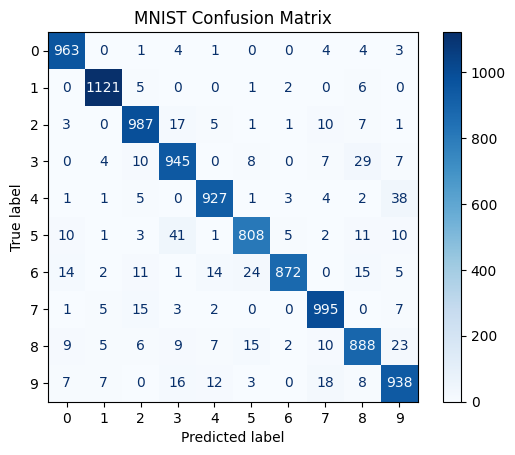

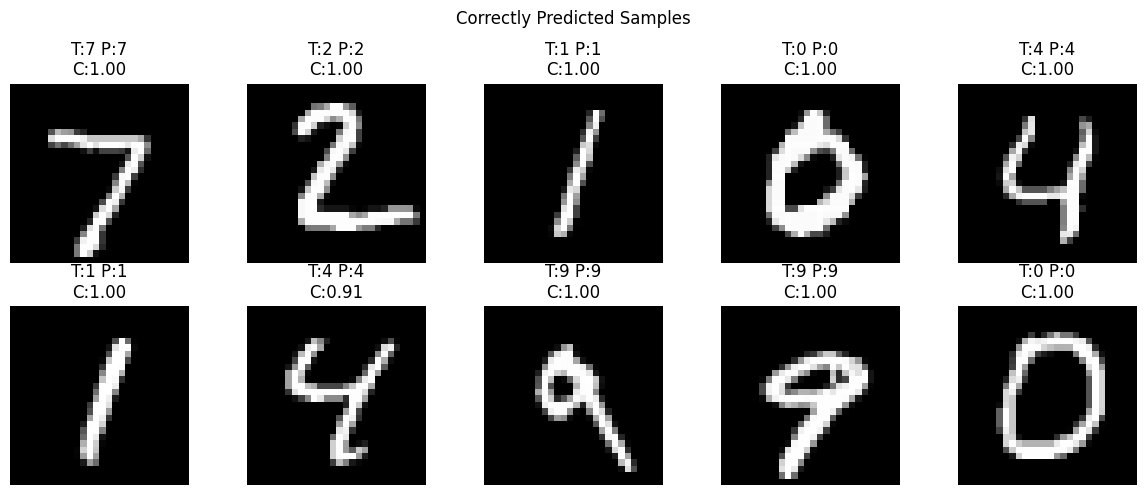

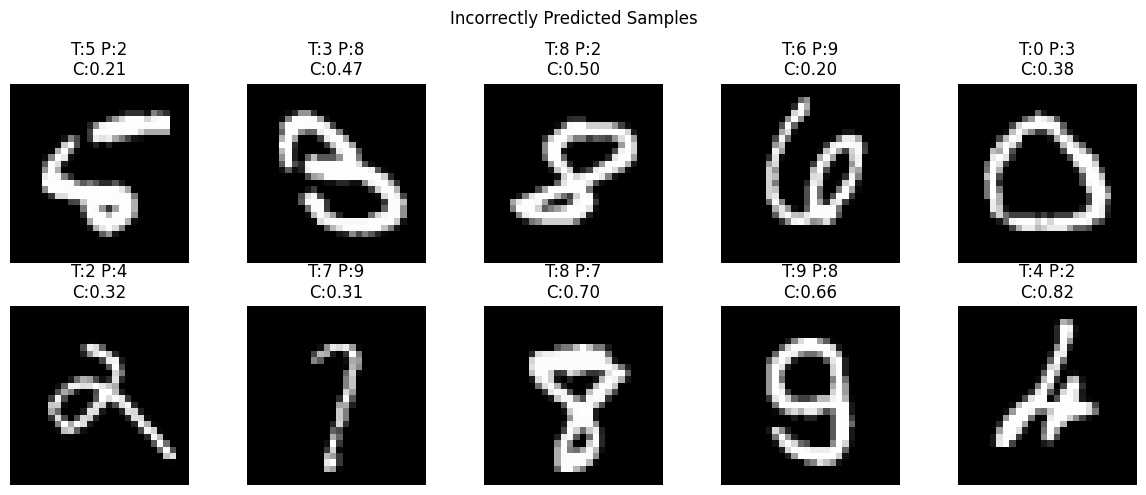

In [44]:
import time
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cuda = torch.cuda.is_available()
batch_size = 1
train_loader, test_loader = create_data_generator(batch_size)

model = DigitNetwork()
if cuda:
    model.cuda()

model.load_state_dict(torch.load("MNIST_Network.pth"))
model.eval()

total_accuracy = 0.0
all_labels = []
all_preds = []

correct_samples = []
incorrect_samples = []

# inference timing for one sample
with torch.no_grad():
    images, labels = next(iter(test_loader))
    if cuda:
        images = images.cuda()
    start_time = time.time()
    outputs = model(images)
    end_time = time.time()

inference_time = end_time - start_time
print("Inference time for one sample: %0.6f seconds" % inference_time)

with torch.no_grad():
    for idx, (images, labels) in enumerate(test_loader):
        if cuda:
            images = images.cuda()
            labels = labels.cuda()

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)

        accuracy = (preds == labels).float().mean().item()
        total_accuracy += accuracy

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        sample = (
            images.squeeze().cpu().numpy(),
            labels.item(),
            preds.item(),
            confs.item()
        )

        if preds.item() == labels.item() and len(correct_samples) < 10:
            correct_samples.append(sample)
        elif preds.item() != labels.item() and len(incorrect_samples) < 10:
            incorrect_samples.append(sample)

        if idx % 2000 == 0:
            print("Iter [%d/%d]. Accuracy: %0.2f" % (idx + 1, len(test_loader), accuracy))

final_accuracy = total_accuracy / len(test_loader)
print("Final Accuracy: %0.4f" % final_accuracy)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MNIST Confusion Matrix")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Correctly Predicted Samples")
for ax, sample in zip(axes.flatten(), correct_samples):
    image, label, pred, conf = sample
    ax.imshow(image, cmap="gray")
    ax.set_title(f"T:{label} P:{pred}\nC:{conf:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

if len(incorrect_samples) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle("Incorrectly Predicted Samples")
    for ax, sample in zip(axes.flatten(), incorrect_samples):
        image, label, pred, conf = sample
        ax.imshow(image, cmap="gray")
        ax.set_title(f"T:{label} P:{pred}\nC:{conf:.2f}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Backpropagation

### ReLU Example

In [45]:
# https://pytorch.org/tutorials/beginner/pytorch_with_examples.html#pytorch-defining-new-autograd-functions
class MyReLU(torch.autograd.Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """

    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        ctx.save_for_backward(input)
        return input.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad_input[input < 0] = 0
        return grad_input

#### Sigmoid Function


In [46]:
class MySigmoid(torch.autograd.Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """

    @staticmethod
    def forward(ctx, input):
      # input is a N x C tensor, N is the batch size, C is the dimension of input
      sigmoid = 1 / (1 + torch.exp(-input))
      ctx.save_for_backward(sigmoid)
      return sigmoid

    @staticmethod
    def backward(ctx, grad_output):
      sigmoid, = ctx.saved_tensors          # instead of recomputing, just reuse it
      grad_input = grad_output * sigmoid * (1 - sigmoid)
      return grad_input

#### Fully Connected Layer

In [47]:
class MyLinearFunction(torch.autograd.Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """

    @staticmethod
    def forward(ctx, input, weights, bias):
        # input is a N x C tensor, N is the batch size, C is the dimension of input
        # weights is a C x D tensor, C and D are the dimension out input and ouput
        # bias is D tensor
        ctx.save_for_backward(input, weights, bias)
        return torch.matmul(input, weights) + bias


    @staticmethod
    def backward(ctx, grad_output):
        input, weights, bias = ctx.saved_tensors
        # return grad_input, grad_weights, grad_bias

        # Gradient w.r.t input
        grad_input = torch.matmul(grad_output, weights.t())

        # Gradient w.r.t weights
        grad_weights = torch.matmul(input.t(), grad_output)

        # Gradient w.r.t bias
        grad_bias = grad_output.sum(dim=0)

        return grad_input, grad_weights, grad_bias


class MyLinearLayer(nn.Module):
  # You don't modify this layer
  def __init__(self, in_features = 2, out_features = 4):
    super(MyLinearLayer, self).__init__()
    self.weights = nn.Parameter(torch.randn(in_features, out_features))
    self.bias = nn.Parameter(torch.zeros(out_features))
    self.linear_fn = MyLinearFunction.apply

  def forward(self, input):
    return self.linear_fn(input, self.weights, self.bias)


#### Testing Your Implementation

In [48]:
class MyLinearNetwork(nn.Module):
  def __init__(self):
    super(MyLinearNetwork, self).__init__()
    self.linear_1 = MyLinearLayer(28 * 28, 128)
    self.sigmoid_fn = MySigmoid.apply
    self.linear_2 = MyLinearLayer(128, 10)
    self.softmax_fn = nn.Softmax(dim=1)

  def forward(self, x):
    size = x.size()
    x = x.reshape(size[0], -1) # Flatten images
    x = self.linear_1(x)
    x = self.sigmoid_fn(x)
    x = self.linear_2(x)
    if self.training == False:
      x = self.softmax_fn(x)
    return x

In [49]:
cuda = torch.cuda.is_available()
batch_size = 32
train_loader, test_loader = create_data_generator(batch_size)
model = MyLinearNetwork()
print(model)
if cuda:
  model.cuda()
n_epochs = 3
learning_rate = 0.1
optim = torch.optim.SGD(params = model.parameters(), lr = learning_rate, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

model.train()
for epoch in range(1, n_epochs + 1):
  for idx, (images, labels) in enumerate(train_loader):
    # WRITE YOUR CODE TO COMPUTE OUTPUTS, LOSS, ACCURACY, AND OPTIMIZE MODEL
    # outptus = ???
    # loss = ???
    # accuracy = ???
    # optimize the model
    if cuda:
      images = images.cuda()
      labels = labels.cuda()

    outputs = model(images)
    loss = loss_fn(outputs, labels)

    _, predicted = torch.max(outputs, dim=1)
    accuracy = (predicted == labels).float().mean().item()

    optim.zero_grad()
    loss.backward()
    optim.step()


    if idx % 100 == 0:
      print("Epoch [%d/%d]. Iter [%d/%d]. Loss: %0.2f. Accuracy: %0.2f" % (epoch, n_epochs, idx + 1, len(train_loader), loss.item(), accuracy))

total_accuracy = 0.0
model.eval()
with torch.no_grad():
  for idx, (images, labels) in enumerate(test_loader):
    # WRITE YOUR CODE TO COMPUTE ACCURACY
    # accuracy = ???

    if cuda:
        images = images.cuda()
        labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs, dim=1)
    accuracy = (predicted == labels).float().mean().item()

    total_accuracy += accuracy

    if idx % 2000 == 0:
      print("Iter [%d/%d]. Accuracy: %0.2f" % (idx + 1, len(test_loader), accuracy))

print("Final Accuracy: %0.2f" % (total_accuracy / len(test_loader)))

MyLinearNetwork(
  (linear_1): MyLinearLayer()
  (linear_2): MyLinearLayer()
  (softmax_fn): Softmax(dim=1)
)
Epoch [1/3]. Iter [1/1875]. Loss: 12.52. Accuracy: 0.06
Epoch [1/3]. Iter [101/1875]. Loss: 0.78. Accuracy: 0.81
Epoch [1/3]. Iter [201/1875]. Loss: 0.82. Accuracy: 0.88
Epoch [1/3]. Iter [301/1875]. Loss: 0.53. Accuracy: 0.91
Epoch [1/3]. Iter [401/1875]. Loss: 0.68. Accuracy: 0.78
Epoch [1/3]. Iter [501/1875]. Loss: 0.94. Accuracy: 0.84
Epoch [1/3]. Iter [601/1875]. Loss: 0.44. Accuracy: 0.91
Epoch [1/3]. Iter [701/1875]. Loss: 0.49. Accuracy: 0.97
Epoch [1/3]. Iter [801/1875]. Loss: 0.12. Accuracy: 0.94
Epoch [1/3]. Iter [901/1875]. Loss: 0.56. Accuracy: 0.84
Epoch [1/3]. Iter [1001/1875]. Loss: 0.57. Accuracy: 0.81
Epoch [1/3]. Iter [1101/1875]. Loss: 0.19. Accuracy: 0.94
Epoch [1/3]. Iter [1201/1875]. Loss: 0.05. Accuracy: 1.00
Epoch [1/3]. Iter [1301/1875]. Loss: 0.13. Accuracy: 0.97
Epoch [1/3]. Iter [1401/1875]. Loss: 0.17. Accuracy: 0.97
Epoch [1/3]. Iter [1501/1875]. 